# Assignment 5: Histogram Processing

## Question 1: Histogram Equalization

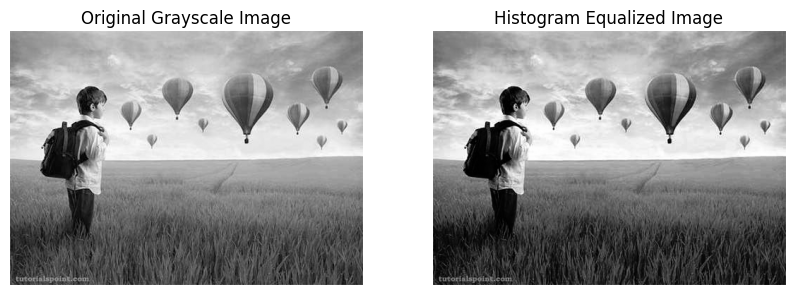

In [ ]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('grayscale.jpg', cv2.IMREAD_GRAYSCALE)

equalized_image = cv2.equalizeHist(image)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(equalized_image, cmap='gray')
plt.title('Histogram Equalized Image')
plt.axis('off')

plt.show()

## Question 2: Histogram Matching

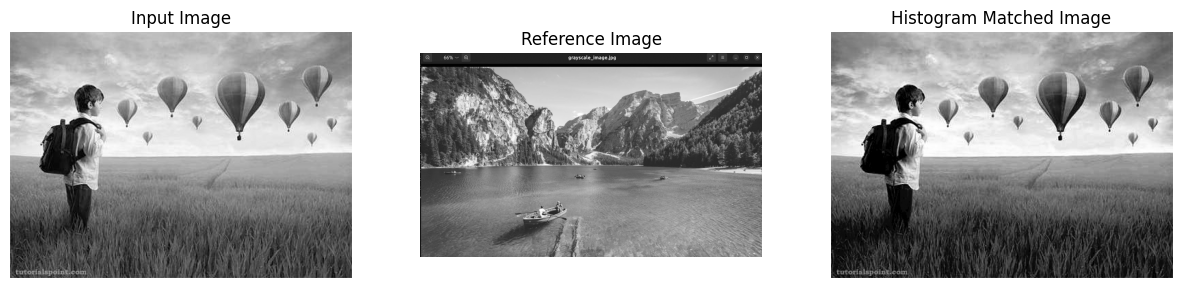

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

input_image = cv2.imread('grayscale.jpg', cv2.IMREAD_GRAYSCALE)

reference_image = cv2.imread('reference.jpeg', cv2.IMREAD_GRAYSCALE)

input_equalized = cv2.equalizeHist(input_image)
reference_equalized = cv2.equalizeHist(reference_image)

hist_input, _ = np.histogram(input_equalized.flatten(), 256, [0, 256])
hist_reference, _ = np.histogram(reference_equalized.flatten(), 256, [0, 256])

cdf_input = hist_input.cumsum()
cdf_reference = hist_reference.cumsum()

cdf_input = cdf_input / cdf_input[-1]
cdf_reference = cdf_reference / cdf_reference[-1]

mapping = np.interp(cdf_input, cdf_reference, np.arange(256))

matched_image = mapping[input_equalized].astype(np.uint8)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(input_image, cmap='gray')
plt.title('Input Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(reference_image, cmap='gray')
plt.title('Reference Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(matched_image, cmap='gray')
plt.title('Histogram Matched Image')
plt.axis('off')

plt.show()